# Exposing the compressor nonlinearity — **CL1B** (TubeTech CL 1B)

The CL1B counterpart of `eval_output_transformer_nonlinearity.ipynb`, applied to
the **TubeTech CL 1B** optical-compressor hardware dataset. Same four measures,
same one-pass Welch machinery; only the dataset front-end changes.

A compressor is, to first order, a **slowly time-varying broadband real gain**
`g(t)`. Within one short STFT window the wet is `Y(f) ~= g*X(f)` -- a scalar,
frequency-flat multiple of the input -- so at the per-bin / matched-time level the
dry->wet relation is almost perfectly *linear*. The nonlinearity lives in **how
`g(t)` is driven by the signal envelope** (threshold / ratio / attack / release)
and in the harmonic coloration it adds, neither of which a two-signal linear
coherence can see. The four measures below surface it:

1. **Best-linear-model residual / NMSE** -- fraction of output power that *no*
   per-frequency LTI filter can explain `= Sum Syy(1-gamma^2) / Sum Syy`. (No
   controlled test tones on program material, so this model-based residual is the
   data-driven analogue of THD.)
2. **Gain-matched residual spectrum** -- apply the known broadband GR envelope
   `g(t)`, then look at the spectrum of `r = wet - g*dry`. With the level/dynamics
   removed, what remains is the residual **coloration + harmonic distortion**.
3. **Envelope multiple-coherence** -- add the envelope-modulated input `m = g*dry`
   as a *second* regressor and compute `gamma^2_{y:x,m}`. The **gap** over ordinary
   coherence is the output power explained only by the time-varying gain.
4. **Bicoherence** -- a higher-order (third-moment) spectrum that detects
   **quadratic phase coupling**.

### CL1B specifics

* **Audio scale.** Each setting is one **stereo WAV** with *dry = left*,
  *wet = right* (16-bit PCM). The raw integer scale reaches the +-10 000 range, but
  `soundfile` reads PCM into floats normalised to `[-1, 1]` (dry ~= +-0.5 here), and
  the whole analysis is **scale-relative** anyway: `gr_db = RMS_dB(wet) - RMS_dB(dry)`
  is a ratio, and `m = g*dry`, `r = wet - g*dry` keep dry and wet in the *same*
  read scale (two channels of one file) -- so the read scaling cancels.
* **Gain-matched front-end.** Reuses the **pre-computed** `gr_curves/*.pt`
  (RMS-window 1024, same as the output-transformer notebook), clamped to
  `[GR_DB_MIN, GR_DB_MAX]`.
* **Settings.** The full set is 620 (attack x release x ratio x threshold). To keep
  the figures legible we hold the **dynamics fixed** (mid attack/release) and sweep
  the **static** params -- a 5x5 grid of **ratio x threshold** -- colouring each
  curve by a continuous **compression-severity** score instead of a 25-entry legend.

All STFT framing uses **librosa**, matching the other nonlinearity notebooks.

In [1]:
import os
import sys
import re
import glob
import gc
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import librosa
import soundfile as sf
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

warnings.filterwarnings("ignore", category=UserWarning)

REPO_ROOT = next(
    (p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (p / "pyproject.toml").is_file()),
    Path.cwd().resolve(),
)
sys.path.insert(0, str(REPO_ROOT / "06_output"))

from amplitude_match import GR_DB_MIN, GR_DB_MAX, gr_db_to_gain

print(f"repo    : {REPO_ROOT}")
print(f"torch   : {torch.__version__}")
print(f"librosa : {librosa.__version__}")
print(f"GR clamp: [{GR_DB_MIN}, {GR_DB_MAX}] dB")

repo    : /Volumes/Saola's Drive/AllCode/thesis/Virtual-Analogue-Compressor-Modelling
torch   : 2.10.0
librosa : 0.11.0
GR clamp: [-30.0, 5.0] dB


In [2]:
# TubeTech CL 1B
DATA_ROOT = "/Volumes/Saola's Drive/AllCode/thesis/data/CL1B"
SAMPLE_RATE = 48000

# 210-220 s files: cap analysed duration per setting (plenty of frames for averaging).
ANALYZE_SEC_PER_PAIR = 120.0
STREAM_CHUNK_SEC = 20.0

# --- Static-parameter sweep: hold the dynamics fixed, vary ratio x threshold. ---
# CL1B attack/release are arbitrary integers 0 (fast) .. 4 (slow); 2 = mid.
FIX_ATTACK = 2
FIX_RELEASE = 2

# --- STFT / spectral-averaging parameters (librosa) ---
N_FFT = 4096
HOP_LENGTH = N_FFT // 4
WINDOW = "hann"
EPS = 1e-12

# Set to a small integer for smoke tests (limits settings analysed)
MAX_EVAL_SETTINGS = None

assert os.path.isdir(DATA_ROOT), f"Missing DATA_ROOT: {DATA_ROOT}"
assert os.path.isdir(os.path.join(DATA_ROOT, "gr_curves")), "Missing gr_curves folder"

# TubeTech_a_{attack}_r_{release}_r_{ratio}_t_{threshold}_g_{gain}.wav
_NAME_RE = re.compile(r"TubeTech_a_(\d+)_r_(\d+)_r_(\d+)_t_(\d+)_g_(\d+)\.wav$")


def discover_cl1b_pairs(data_root: str) -> list[dict]:
    '''One stereo WAV per setting (dry=L, wet=R) + matching gr_curves/*.pt.'''
    pairs = []
    for folder in range(5):  # directory number == release value
        for wav in sorted(glob.glob(os.path.join(data_root, str(folder), "TubeTech_*.wav"))):
            m = _NAME_RE.search(os.path.basename(wav))
            if not m:
                continue
            a, rel, ratio, thr, gain = (int(x) for x in m.groups())
            stem = os.path.splitext(os.path.basename(wav))[0]
            gr = os.path.join(data_root, "gr_curves", str(folder), f"{stem}.pt")
            pairs.append({
                "stem": stem, "folder": folder, "attack": a, "release": rel,
                "ratio": ratio, "threshold": thr, "gain": gain, "wav": wav, "gr": gr,
            })
    return sorted(pairs, key=lambda p: (p["threshold"], p["ratio"], p["attack"], p["release"]))


ALL_PAIRS = discover_cl1b_pairs(DATA_ROOT)
SWEEP = [p for p in ALL_PAIRS if p["attack"] == FIX_ATTACK and p["release"] == FIX_RELEASE]
SWEEP = [p for p in SWEEP if os.path.isfile(p["gr"])]
if MAX_EVAL_SETTINGS is not None:
    SWEEP = SWEEP[:MAX_EVAL_SETTINGS]


# setting key = "ratioR_threshT" (threshold filename value; device label = -T dB)
def setting_key(p: dict) -> str:
    return f"ratio{p['ratio']}_th{p['threshold']}"


PAIR_BY_SETTING = {setting_key(p): p for p in SWEEP}
SETTINGS = list(PAIR_BY_SETTING.keys())

print(f"Total CL1B settings           : {len(ALL_PAIRS)}")
print(f"Sweep (a={FIX_ATTACK}, rel={FIX_RELEASE}) : {len(SWEEP)} settings "
      f"(ratios={sorted({p['ratio'] for p in SWEEP})}, "
      f"thresholds(-dB)={sorted({p['threshold'] for p in SWEEP})})")

chunk_frames = int(round(STREAM_CHUNK_SEC * SAMPLE_RATE))
analyze_frames = int(round(ANALYZE_SEC_PER_PAIR * SAMPLE_RATE))
FREQS = librosa.fft_frequencies(sr=SAMPLE_RATE, n_fft=N_FFT)
print(f"Analyse {ANALYZE_SEC_PER_PAIR:.0f}s/setting | n_fft={N_FFT}, hop={HOP_LENGTH} "
      f"-> {len(FREQS)} freq bins")

Total CL1B settings           : 620
Sweep (a=2, rel=2) : 25 settings (ratios=[2, 4, 6, 8, 10], thresholds(-dB)=[0, 10, 20, 30, 40])


Analyse 120s/setting | n_fft=4096, hop=1024 -> 2049 freq bins


## CL1B stereo reader + shared one-pass accumulator

CL1B packs **dry (left) and wet (right) in one stereo file**, so the shared
`eval_helpers._read_dry_wet_segment` (which mean-collapses channels) does not
apply -- a small reader splits the two channels instead. The accumulator is
**identical** to the output-transformer / LA2A notebooks: a single streaming pass
per setting computes the STFTs of dry `X`, wet `Y` and gain-matched `M = g*dry`
and accumulates every Welch sum the four measures need
(`Sxx, Syy, Smm, Sxy, Sxm, Smy` and `Srr = Sum|Y - M|^2`). The gain-matched input
is `dry * 10**(gr_db/20)` with `gr_db` read from the pre-computed `gr_curves/*.pt`,
clamped to `[GR_DB_MIN, GR_DB_MAX]`.

In [3]:
def cl1b_num_frames(wav_path: str) -> int:
    return sf.info(wav_path).frames


def read_cl1b_segment(wav_path: str, start: int, stop: int):
    '''Return (dry, wet) as [1, T] float32 tensors from one stereo CL1B WAV.'''
    audio, sr = sf.read(wav_path, start=start, stop=stop, dtype="float32", always_2d=True)
    if sr != SAMPLE_RATE:
        raise ValueError(f"{wav_path}: expected {SAMPLE_RATE} Hz, got {sr}")
    dry = torch.from_numpy(audio[:, 0]).unsqueeze(0)   # left  = dry
    wet = torch.from_numpy(audio[:, 1]).unsqueeze(0)   # right = wet
    return dry, wet


def _stft(sig: np.ndarray) -> np.ndarray:
    return librosa.stft(
        np.ascontiguousarray(sig, dtype=np.float32),
        n_fft=N_FFT, hop_length=HOP_LENGTH, window=WINDOW, center=False,
    )


class NLAccumulator:
    '''Welch sums for the dry (X), wet (Y) and gain-matched (M) signals.'''

    def __init__(self, n_bins: int):
        self.Sxx = np.zeros(n_bins, np.float64)
        self.Syy = np.zeros(n_bins, np.float64)
        self.Smm = np.zeros(n_bins, np.float64)
        self.Sxy = np.zeros(n_bins, np.complex128)
        self.Sxm = np.zeros(n_bins, np.complex128)
        self.Smy = np.zeros(n_bins, np.complex128)
        self.Srr = np.zeros(n_bins, np.float64)   # |Y - M|^2
        self.n_frames = 0

    def add(self, x, y, m):
        if min(len(x), len(y), len(m)) < N_FFT:
            return
        X, Y, M = _stft(x), _stft(y), _stft(m)
        self.Sxx += np.sum(np.abs(X) ** 2, axis=1)
        self.Syy += np.sum(np.abs(Y) ** 2, axis=1)
        self.Smm += np.sum(np.abs(M) ** 2, axis=1)
        self.Sxy += np.sum(np.conj(X) * Y, axis=1)
        self.Sxm += np.sum(np.conj(X) * M, axis=1)
        self.Smy += np.sum(np.conj(M) * Y, axis=1)
        self.Srr += np.sum(np.abs(Y - M) ** 2, axis=1)
        self.n_frames += X.shape[1]

    # 1 -----------------------------------------------------------------
    def coherence(self):
        return (np.abs(self.Sxy) ** 2) / (self.Sxx * self.Syy + EPS)

    def linear_unexplained(self):
        '''Per-bin output power fraction no LTI filter can explain = 1 - gamma^2.'''
        return 1.0 - self.coherence()

    # 2 -----------------------------------------------------------------
    def distortion_ratio(self):
        '''Gain-matched residual / output power, per bin (linear ratio).'''
        return self.Srr / (self.Syy + EPS)

    # 3 -----------------------------------------------------------------
    def multiple_coherence(self, ridge=1e-9):
        '''gamma^2_{y:(x,m)} via per-bin 2x2 cross-spectral solve.'''
        a = self.Sxx + ridge
        d = self.Smm + ridge
        b = self.Sxm                     # c = conj(b)
        det = a * d - np.abs(b) ** 2 + EPS
        p, q = self.Sxy, self.Smy        # b_vec = [Sxy, Smy]
        inv0 = (d * p - b * q) / det                 # (Sxx^-1 b_vec)[0]
        inv1 = (-np.conj(b) * p + a * q) / det       # (Sxx^-1 b_vec)[1]
        num = np.real(np.conj(p) * inv0 + np.conj(q) * inv1)
        return np.clip(num / (self.Syy + EPS), 0.0, 1.0)


@torch.no_grad()
def accumulate_setting(pair: dict, acc: NLAccumulator, max_frames: int) -> None:
    '''Stream one CL1B setting (single stereo WAV + gr_curve) into the accumulator.'''
    gr_obj = torch.load(pair["gr"], weights_only=False, map_location="cpu")
    gr_db_full = gr_obj["gr_db"].float()
    if gr_db_full.ndim == 1:
        gr_db_full = gr_db_full.unsqueeze(0)
    if gr_db_full.shape[0] > 1:
        gr_db_full = gr_db_full.mean(dim=0, keepdim=True)

    total = min(cl1b_num_frames(pair["wav"]), gr_db_full.shape[-1], max_frames)
    for o in range(0, total, chunk_frames):
        stop = min(o + chunk_frames, total)
        dry, wet = read_cl1b_segment(pair["wav"], o, stop)
        L = min(dry.shape[-1], wet.shape[-1])
        if L < N_FFT:
            continue
        dry, wet = dry[..., :L], wet[..., :L]
        gr_db = gr_db_full[..., o : o + L].clamp(GR_DB_MIN, GR_DB_MAX)
        matched = dry * gr_db_to_gain(gr_db, clamp=False)
        acc.add(dry.squeeze(0).numpy(), wet.squeeze(0).numpy(), matched.squeeze(0).numpy())
    gc.collect()


# Run the single pass per setting.
results = {}
for si, key in enumerate(SETTINGS, start=1):
    pair = PAIR_BY_SETTING[key]
    acc = NLAccumulator(len(FREQS))
    print(f"[{si}/{len(SETTINGS)}] {key:18s} ({pair['stem']})")
    accumulate_setting(pair, acc, analyze_frames)
    results[key] = {"acc": acc, "pair": pair}

print("\nFrames per setting:")
for key in SETTINGS:
    print(f"  {key:18s} {results[key]['acc'].n_frames:>7d}")

[1/25] ratio2_th0         (TubeTech_a_2_r_2_r_2_t_0_g_0)


[2/25] ratio4_th0         (TubeTech_a_2_r_2_r_4_t_0_g_0)


[3/25] ratio6_th0         (TubeTech_a_2_r_2_r_6_t_0_g_0)


[4/25] ratio8_th0         (TubeTech_a_2_r_2_r_8_t_0_g_0)


[5/25] ratio10_th0        (TubeTech_a_2_r_2_r_10_t_0_g_0)


...

[22/25] ratio4_th40        (TubeTech_a_2_r_2_r_4_t_40_g_0)


[23/25] ratio6_th40        (TubeTech_a_2_r_2_r_6_t_40_g_0)


[24/25] ratio8_th40        (TubeTech_a_2_r_2_r_8_t_40_g_0)


[25/25] ratio10_th40       (TubeTech_a_2_r_2_r_10_t_40_g_0)



Frames per setting:
  ratio2_th0            5604
  ratio4_th0            5604
  ratio6_th0            5604
  ratio8_th0            5604
  ratio10_th0           5604
  ratio2_th10           5604
  ratio4_th10           5604
  ratio6_th10           5604
  ratio8_th10           5604
  ratio10_th10          5604
  ratio2_th20           5604
  ratio4_th20           5604
  ratio6_th20           5604
  ratio8_th20           5604
  ratio10_th20          5604
  ratio2_th30           5604
  ratio4_th30           5604
  ratio6_th30           5604
  ratio8_th30           5604
  ratio10_th30          5604
  ratio2_th40           5604
  ratio4_th40           5604
  ratio6_th40           5604
  ratio8_th40           5604
  ratio10_th40          5604


In [4]:
F_MIN, F_MAX = 20.0, SAMPLE_RATE / 2
fmask = (FREQS >= F_MIN) & (FREQS <= F_MAX)
band = (FREQS >= 200) & (FREQS <= 8000)          # broadband summary band

RATIOS = sorted({results[k]["pair"]["ratio"] for k in SETTINGS})
THRESHS = sorted({results[k]["pair"]["threshold"] for k in SETTINGS})
R_MIN, R_MAX = min(RATIOS), max(RATIOS)
T_MIN, T_MAX = min(THRESHS), max(THRESHS)


def severity(key: str) -> float:
    '''Continuous compression severity in [0,1]: deeper threshold + higher ratio = harder.'''
    p = results[key]["pair"]
    t = (p["threshold"] - T_MIN) / max(T_MAX - T_MIN, 1)
    r = (p["ratio"] - R_MIN) / max(R_MAX - R_MIN, 1)
    return 0.5 * t + 0.5 * r


def short_label(key: str) -> str:
    p = results[key]["pair"]
    return f"ratio {p['ratio']}:1, thr -{p['threshold']} dB"


SEV_NORM = Normalize(vmin=0.0, vmax=1.0)
SEV_CMAP = plt.get_cmap("viridis")


def setting_color(key: str):
    return SEV_CMAP(SEV_NORM(severity(key)))


# Order by severity (hardest first): deepest threshold, then highest ratio.
SETTINGS_BY_SEV = sorted(SETTINGS, key=severity, reverse=True)
HARDEST = SETTINGS_BY_SEV[0]
print(f"Hardest setting (severity): {HARDEST}  ->  {short_label(HARDEST)}")
print(f"Softest setting (severity): {SETTINGS_BY_SEV[-1]}  ->  {short_label(SETTINGS_BY_SEV[-1])}")

Hardest setting (severity): ratio10_th40  ->  ratio 10:1, thr -40 dB
Softest setting (severity): ratio2_th0  ->  ratio 2:1, thr -0 dB


## 1 -- Best-linear-model residual / NMSE

For every frequency bin the **optimal** per-bin LTI transfer is `H1 = Sxy/Sxx`;
the output power it leaves unexplained is `Syy*(1-gamma^2)`. Summed over the band
this is the **NMSE of the best linear time-invariant model** -- the share of the
wet that *no* fixed filter of the dry can reproduce. A truly linear box floors
near the recording noise; the CL 1B pushes it up, and **harder settings push it
higher**. Curves: `10*log10(1-gamma^2)` per frequency, coloured by compression
severity.

/var/folders/dz/8hnv7ygd6s79yrj4j80lm15m0000gn/T/ipykernel_27645/4059808822.py:4: RuntimeWarning: invalid value encountered in log10
  unexp_db = 10 * np.log10(acc.linear_unexplained() + EPS)


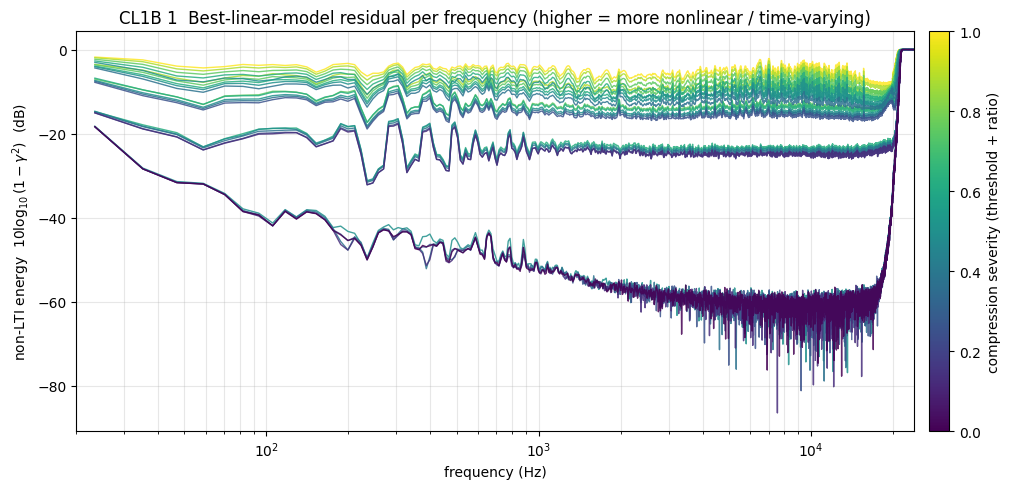

Broadband (200 Hz-8 kHz) best-LTI NMSE, ordered hardest -> softest:
  ratio 10:1, thr -40 dB      NMSE =   -4.65 dB
  ratio 10:1, thr -30 dB      NMSE =   -7.76 dB
  ratio 8:1, thr -40 dB       NMSE =   -5.32 dB
  ratio 10:1, thr -20 dB      NMSE =  -12.77 dB
  ratio 8:1, thr -30 dB       NMSE =   -8.46 dB
  ratio 6:1, thr -40 dB       NMSE =   -6.23 dB
  ratio 10:1, thr -10 dB      NMSE =  -22.15 dB
  ratio 8:1, thr -20 dB       NMSE =  -12.96 dB
  ratio 6:1, thr -30 dB       NMSE =   -9.29 dB
  ratio 4:1, thr -40 dB       NMSE =   -7.29 dB
  ratio 10:1, thr -0 dB       NMSE =  -48.26 dB
  ratio 8:1, thr -10 dB       NMSE =  -22.32 dB
  ratio 6:1, thr -20 dB       NMSE =  -13.82 dB
  ratio 4:1, thr -30 dB       NMSE =   -9.91 dB
  ratio 2:1, thr -40 dB       NMSE =   -8.51 dB
  ratio 8:1, thr -0 dB        NMSE =  -49.54 dB
  ratio 6:1, thr -10 dB       NMSE =  -22.77 dB
  ratio 4:1, thr -20 dB       NMSE =  -14.23 dB
  ratio 2:1, thr -30 dB       NMSE =  -10.75 dB
  ratio 6:1, thr -0 

In [5]:
fig, ax = plt.subplots(figsize=(11, 5))
for key in SETTINGS_BY_SEV:
    acc = results[key]["acc"]
    unexp_db = 10 * np.log10(acc.linear_unexplained() + EPS)
    ax.semilogx(FREQS[fmask], unexp_db[fmask], color=setting_color(key), lw=1.0, alpha=0.85)
ax.set_xlabel("frequency (Hz)")
ax.set_ylabel(r"non-LTI energy  $10\log_{10}(1-\gamma^2)$  (dB)")
ax.set_title("CL1B 1  Best-linear-model residual per frequency (higher = more nonlinear / time-varying)")
ax.set_xlim(F_MIN, F_MAX)
ax.grid(True, which="both", alpha=0.3)
sm = ScalarMappable(norm=SEV_NORM, cmap=SEV_CMAP); sm.set_array([])
fig.colorbar(sm, ax=ax, label="compression severity (threshold + ratio)", pad=0.015)
plt.tight_layout(); plt.show()

print("Broadband (200 Hz-8 kHz) best-LTI NMSE, ordered hardest -> softest:")
for key in SETTINGS_BY_SEV:
    acc = results[key]["acc"]
    nmse = np.sum(acc.Syy[band] * acc.linear_unexplained()[band]) / (np.sum(acc.Syy[band]) + EPS)
    print(f"  {short_label(key):26s}  NMSE = {10*np.log10(nmse + EPS):7.2f} dB")

## 2 -- Gain-matched residual spectrum

Remove the compressor's level/dynamics with the **pre-computed** broadband GR
envelope `g(t)` (the grey-box front-end used across this project), then inspect
the spectrum of the leftover `r = wet - g*dry`. A pure broadband gain would leave
`r ~= 0`; what actually remains is the CL 1B's frequency-dependent **coloration +
harmonic distortion**. Curves: residual-to-output ratio `10*log10(Srr/Syy)` per
frequency.

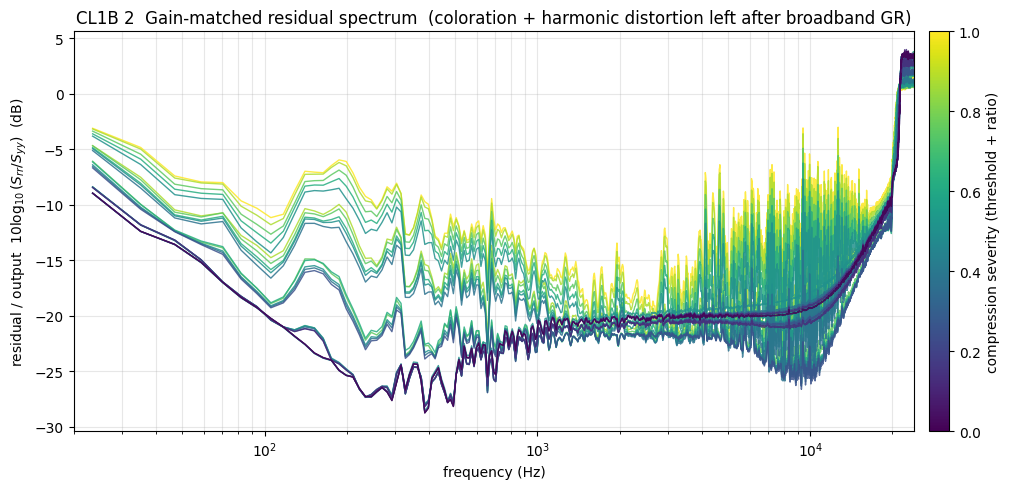

In [6]:
fig, ax = plt.subplots(figsize=(11, 5))
for key in SETTINGS_BY_SEV:
    acc = results[key]["acc"]
    dr_db = 10 * np.log10(acc.distortion_ratio() + EPS)
    ax.semilogx(FREQS[fmask], dr_db[fmask], color=setting_color(key), lw=1.0, alpha=0.85)
ax.set_xlabel("frequency (Hz)")
ax.set_ylabel(r"residual / output  $10\log_{10}(S_{rr}/S_{yy})$  (dB)")
ax.set_title("CL1B 2  Gain-matched residual spectrum  (coloration + harmonic distortion left after broadband GR)")
ax.set_xlim(F_MIN, F_MAX)
ax.grid(True, which="both", alpha=0.3)
sm = ScalarMappable(norm=SEV_NORM, cmap=SEV_CMAP); sm.set_array([])
fig.colorbar(sm, ax=ax, label="compression severity (threshold + ratio)", pad=0.015)
plt.tight_layout(); plt.show()

### Listen — gain-matched residual

The residual `r = wet − g·dry` is exactly the time-domain signal whose spectrum
the cell above plots (the STFT is linear, so `STFT(r) = Y − M`). Subtracting the
broadband gain `g(t)` removes the compressor's level/dynamics and leaves only its
**frequency-dependent coloration + harmonic distortion** — which you can now hear.

The players below render a short excerpt of the hardest setting. The first three (dry,
wet, gain-matched) share a common scale so the compression stays audible across
them; the **residual is peak-normalized** because it is much quieter than the
output (see the printed residual/output level in dB).

In [ ]:
# ---- Listen to the gain-matched residual  r = wet − g·dry  (the audible nonlinearity) ----
from IPython.display import Audio, display

LISTEN_SECONDS = 25.0      # excerpt length rendered as audio players
LISTEN_OFFSET_SEC = 30.0   # skip in to land on musical material (clamped to fit the file)


def _clamp_offset(offset_sec, total, seconds):
    o = int(round(offset_sec * SAMPLE_RATE))
    return min(o, max(total - int(round(seconds * SAMPLE_RATE)), 0))


def residual_excerpt(key, seconds=LISTEN_SECONDS, offset_sec=LISTEN_OFFSET_SEC):
    """Time-domain dry / wet / gain-matched / residual (wet − g·dry) excerpt for one setting."""
    pair = PAIR_BY_SETTING[key]
    gr_obj = torch.load(pair["gr"], weights_only=False, map_location="cpu")
    gr_db_full = gr_obj["gr_db"].float()
    if gr_db_full.ndim == 1:
        gr_db_full = gr_db_full.unsqueeze(0)
    if gr_db_full.shape[0] > 1:
        gr_db_full = gr_db_full.mean(dim=0, keepdim=True)
    total = min(cl1b_num_frames(pair["wav"]), gr_db_full.shape[-1])
    o = _clamp_offset(offset_sec, total, seconds)
    stop = min(o + int(round(seconds * SAMPLE_RATE)), total)
    dry, wet = read_cl1b_segment(pair["wav"], o, stop)
    L = min(dry.shape[-1], wet.shape[-1])
    dry, wet = dry[..., :L], wet[..., :L]
    gr_db = gr_db_full[..., o:o + L].clamp(GR_DB_MIN, GR_DB_MAX)
    matched = dry * gr_db_to_gain(gr_db, clamp=False)
    res = wet - matched
    sq = lambda t: t.squeeze(0).numpy()
    return sq(dry), sq(wet), sq(matched), sq(res)


def play_residual(item, title=None):
    """Render dry / wet / gain-matched / residual audio players for one item."""
    dry, wet, matched, res = residual_excerpt(item)
    rms = lambda a: float(np.sqrt(np.mean(a ** 2)) + EPS)
    print(f"{title or item}")
    print(f"  residual/output = {20*np.log10(rms(res)/rms(wet)):5.1f} dB   "
          f"(peaks: wet {np.max(np.abs(wet)):.3f}, residual {np.max(np.abs(res)):.4f})")
    shared = max(np.max(np.abs(dry)), np.max(np.abs(wet)), np.max(np.abs(matched)), EPS)
    rpk = max(np.max(np.abs(res)), EPS)
    for name, sig, sc in [
        ("dry  x", dry, shared),
        ("wet  y", wet, shared),
        ("gain-matched  g·x   (broadband GR removed)", matched, shared),
        ("residual  r = y − g·x   [peak-normalized — the audible nonlinearity]", res, rpk),
    ]:
        print("  " + name)
        display(Audio(sig / sc, rate=SAMPLE_RATE, normalize=False))


# Listen to the hardest setting (set to any key in SETTINGS_BY_SEV).
play_residual(HARDEST, title=short_label(HARDEST))


## 3 -- Envelope multiple-coherence

Add the envelope-modulated input `m = g*dry` as a **second regressor** and compute
the multiple coherence `gamma^2_{y:(x,m)}`. Because `g(t)` varies *within* each
window, `STFT(g*x) != g*STFT(x)` -- `m` carries genuinely new (modulation-spread)
structure, so the 2x2 cross-spectral matrix is well-conditioned. The **gap**
`gamma^2_{y:(x,m)} - gamma^2_{yx}` is the output power explained *only* once the
time-varying gain is admitted -- a direct, per-frequency signature of the
envelope-driven nonlinearity. Top: ordinary vs multiple coherence for the hardest
setting. Bottom: the gap for every setting, coloured by severity.

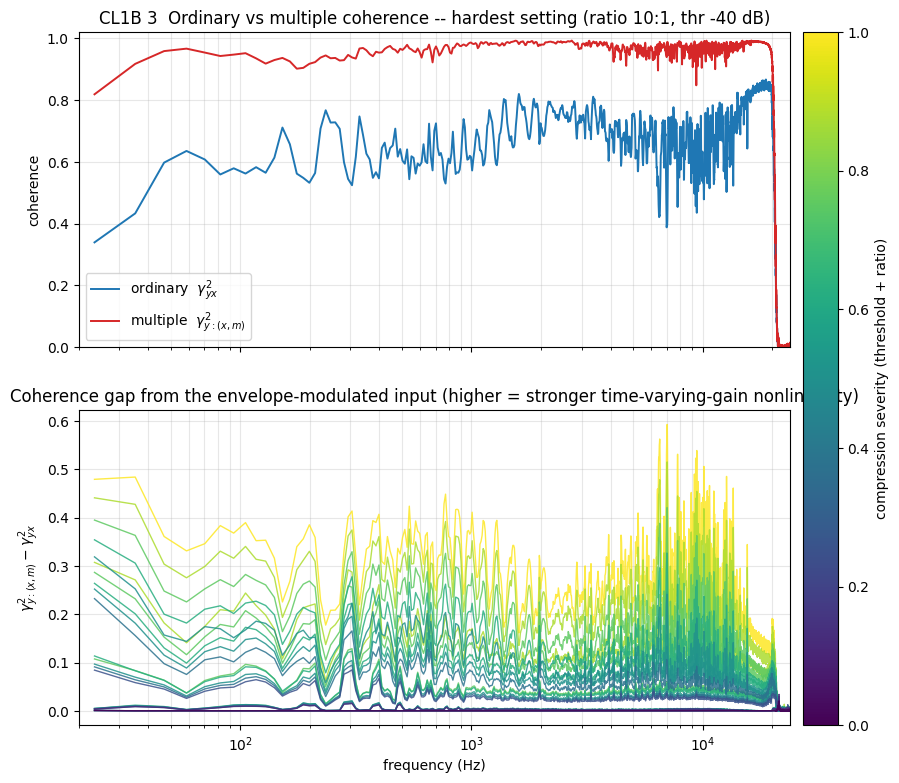

In [7]:
fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(11, 9), sharex=True)

acc_h = results[HARDEST]["acc"]
ax_top.semilogx(FREQS[fmask], acc_h.coherence()[fmask], lw=1.4,
                color="#1f77b4", label=r"ordinary  $\gamma^2_{yx}$")
ax_top.semilogx(FREQS[fmask], acc_h.multiple_coherence()[fmask], lw=1.4,
                color="#d62728", label=r"multiple  $\gamma^2_{y:(x,m)}$")
ax_top.set_ylabel("coherence")
ax_top.set_ylim(0, 1.02)
ax_top.set_title(f"CL1B 3  Ordinary vs multiple coherence -- hardest setting ({short_label(HARDEST)})")
ax_top.grid(True, which="both", alpha=0.3)
ax_top.legend(loc="lower left")

for key in SETTINGS_BY_SEV:
    acc = results[key]["acc"]
    gap = acc.multiple_coherence() - acc.coherence()
    ax_bot.semilogx(FREQS[fmask], gap[fmask], color=setting_color(key), lw=1.0, alpha=0.85)
ax_bot.set_xlabel("frequency (Hz)")
ax_bot.set_ylabel(r"$\gamma^2_{y:(x,m)} - \gamma^2_{yx}$")
ax_bot.set_title("Coherence gap from the envelope-modulated input (higher = stronger time-varying-gain nonlinearity)")
ax_bot.set_xlim(F_MIN, F_MAX)
ax_bot.grid(True, which="both", alpha=0.3)
sm = ScalarMappable(norm=SEV_NORM, cmap=SEV_CMAP); sm.set_array([])
fig.colorbar(sm, ax=[ax_top, ax_bot], label="compression severity (threshold + ratio)", pad=0.015)
plt.show()

## 4 -- Bicoherence (quadratic phase coupling)

The third-order analogue of coherence:

$$b^2(f_1,f_2)=\frac{\left|\;\mathbb{E}\!\left[X(f_1)X(f_2)X^*(f_1{+}f_2)\right]\right|^2}
{\mathbb{E}|X(f_1)X(f_2)|^2\;\cdot\;\mathbb{E}|X(f_1{+}f_2)|^2}.$$

It is ~0 for a linear process with independent-phase components and rises toward 1
where a **quadratic** nonlinearity phase-locks `f_1`, `f_2` and their sum.
Computed on one excerpt of the hardest setting, decimated for tractability. The
**wet** map showing structure absent from the **dry** map is nonlinearly-generated
coupling -- proof the box is not linear, independent of any envelope model.

Bicoherence: ratio 10:1, thr -40 dB (TubeTech_a_2_r_2_r_10_t_40_g_0)  | 11025 Hz, n_fft=256, 129 bins, excerpt 60s


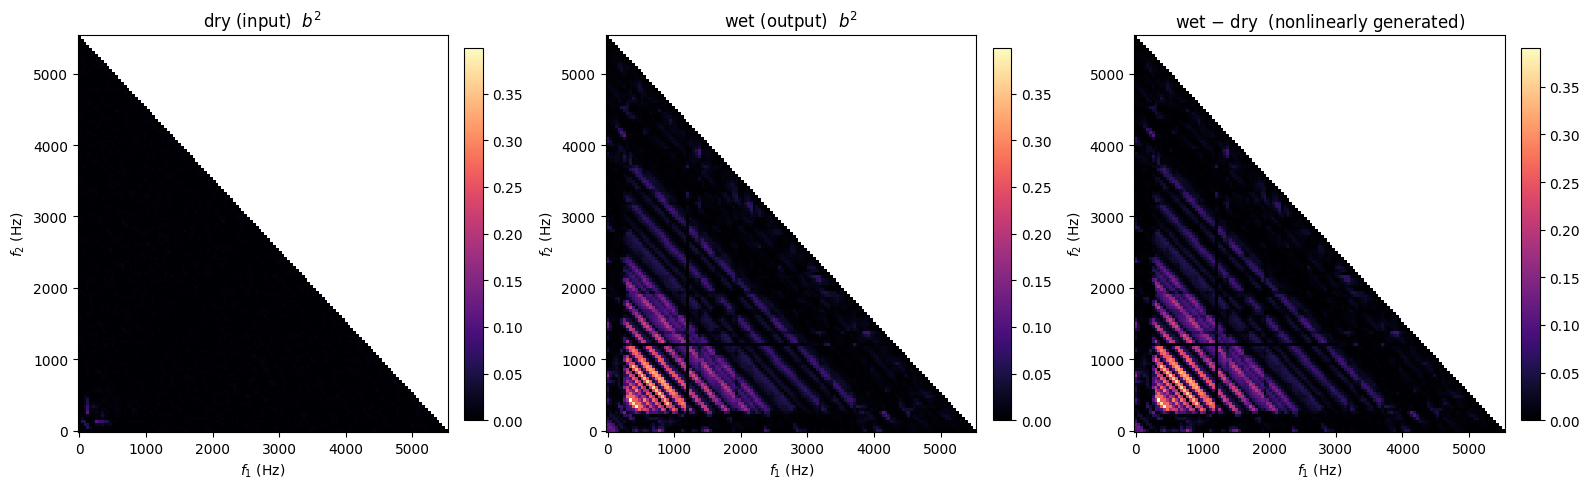

mean bicoherence  dry=0.0023   wet=0.0304   (wet/dry = 13.32x)


In [8]:
# Decimated, single excerpt of the hardest setting (bicoherence is O(F^2)).
BIC_SR = 11025
BIC_NFFT = 256
BIC_HOP = BIC_NFFT // 2
BIC_PAIR = results[HARDEST]["pair"]
BIC_DUR_SEC = 60.0

_total = cl1b_num_frames(BIC_PAIR["wav"])
_stop = min(_total, int(BIC_DUR_SEC * SAMPLE_RATE))
_dry, _wet = read_cl1b_segment(BIC_PAIR["wav"], 0, _stop)
dry_ds = librosa.resample(_dry.squeeze(0).numpy(), orig_sr=SAMPLE_RATE, target_sr=BIC_SR)
wet_ds = librosa.resample(_wet.squeeze(0).numpy(), orig_sr=SAMPLE_RATE, target_sr=BIC_SR)


def bicoherence(sig, nfft, hop):
    S = librosa.stft(np.ascontiguousarray(sig, np.float32), n_fft=nfft,
                     hop_length=hop, window="hann", center=False)   # [F, T]
    F = S.shape[0]
    idx = np.arange(F)
    s = idx[:, None] + idx[None, :]
    valid = s < F
    s_clip = np.where(valid, s, 0)
    num = np.zeros((F, F), np.complex128)
    d1 = np.zeros((F, F), np.float64)
    d2 = np.zeros((F, F), np.float64)
    for t in range(S.shape[1]):
        Xt = S[:, t]
        prod = np.outer(Xt, Xt)            # X(f1) X(f2)
        Xsum = Xt[s_clip]                  # X(f1+f2)
        num += prod * np.conj(Xsum)
        d1 += np.abs(prod) ** 2
        d2 += np.abs(Xsum) ** 2
    b2 = (np.abs(num) ** 2) / (d1 * d2 + EPS)
    b2[~valid] = np.nan
    return b2, librosa.fft_frequencies(sr=BIC_SR, n_fft=nfft)


b2_dry, bfreq = bicoherence(dry_ds, BIC_NFFT, BIC_HOP)
b2_wet, _ = bicoherence(wet_ds, BIC_NFFT, BIC_HOP)
print(f"Bicoherence: {short_label(HARDEST)} ({BIC_PAIR['stem']})  | {BIC_SR} Hz, "
      f"n_fft={BIC_NFFT}, {b2_dry.shape[0]} bins, excerpt {_stop/SAMPLE_RATE:.0f}s")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, data, title in zip(
    axes,
    [b2_dry, b2_wet, b2_wet - b2_dry],
    ["dry (input)  $b^2$", "wet (output)  $b^2$", "wet $-$ dry  (nonlinearly generated)"],
):
    pm = ax.pcolormesh(bfreq, bfreq, data, shading="auto", cmap="magma",
                       vmin=0, vmax=(np.nanmax(b2_wet) if "generated" not in title else None))
    ax.set_title(title)
    ax.set_xlabel("$f_1$ (Hz)")
    ax.set_ylabel("$f_2$ (Hz)")
    fig.colorbar(pm, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()

print(f"mean bicoherence  dry={np.nanmean(b2_dry):.4f}   wet={np.nanmean(b2_wet):.4f}   "
      f"(wet/dry = {np.nanmean(b2_wet)/ (np.nanmean(b2_dry)+EPS):.2f}x)")

## Summary

Per setting (hardest -> softest), the four nonlinearity read-outs over the
200 Hz-8 kHz band. Ordinary coherence is shown for reference -- note how little it
moves while the targeted measures separate the settings.

In [9]:
rows = []
for key in SETTINGS_BY_SEV:
    p = results[key]["pair"]
    acc = results[key]["acc"]
    nmse = np.sum(acc.Syy[band] * acc.linear_unexplained()[band]) / (np.sum(acc.Syy[band]) + EPS)
    rows.append({
        "Setting": key,
        "Ratio": p["ratio"],
        "Thresh(dB)": -p["threshold"],
        "Severity": round(severity(key), 3),
        "Frames": acc.n_frames,
        "ord. coh (ref)": float(np.mean(acc.coherence()[band])),
        "1 best-LTI NMSE dB": 10 * np.log10(nmse + EPS),
        "2 resid/out dB": float(np.mean(10 * np.log10(acc.distortion_ratio()[band] + EPS))),
        "3 multi-coh gap": float(np.mean((acc.multiple_coherence() - acc.coherence())[band])),
    })
summary_df = pd.DataFrame(rows)
display(summary_df.round(4))

,Setting,Ratio,Thresh(dB),Severity,Frames,ord. coh (ref),1 best-LTI NMSE dB,2 resid/out dB,3 multi-coh gap
0,ratio10_th40,10,-40,1.000,5604,0.6810,-4.6510,-14.0621,0.2901
1,ratio10_th30,10,-30,0.875,5604,0.8503,-7.7642,-19.2828,0.1399
2,ratio8_th40,8,-40,0.875,5604,0.7350,-5.3172,-14.7358,0.2399
3,ratio10_th20,10,-20,0.750,5604,0.9534,-12.7717,-22.0726,0.0434
4,ratio8_th30,8,-30,0.750,5604,0.8768,-8.4637,-19.8067,0.1146
5,ratio6_th40,6,-40,0.750,5604,0.7947,-6.2260,-15.8139,0.1856
6,ratio10_th10,10,-10,0.625,5604,0.9950,-22.1470,-20.7214,0.0037
7,ratio8_th20,8,-20,0.625,5604,0.9564,-12.9642,-22.3178,0.0404
8,ratio6_th30,6,-30,0.625,5604,0.9018,-9.2867,-20.3774,0.0909
9,ratio4_th40,4,-40,0.625,5604,0.8478,-7.2915,-16.8560,0.1370
